#Speech Dataset Analysis and Classification
###CS 4403 – Data Mining Term Project

**Group Members :**  
Chanchalpreet Kaur    
Fatima Asif    
Medha Madhub

**Project Goal :**  
The goal of this project is to analyze and compare multiple speech-based text datasets.  
We aim to clean, explore and analyze speech transcripts using data mining techniques.  
The project will involve text preprocessing, visualization of patterns and applying machine learning models to classify and analyze speech data.

**Datasets Used:**  
- TED Talks transcripts dataset (`transcripts.csv`)
- TED Talks metadata dataset (`ted_main.csv`)
- Mozilla Common Voice speech dataset (`cv-valid-train.csv`)
- Synthetic speech dataset (`synthetic_speech_dataset_2000.csv`)


**Tools Used :**  
Python, Pandas, Scikit-learn and data visualization libraries.

---

## Dataset Summary

The project uses three speech based text datasets collected from publicly available sources:

• **TED Talks transcripts dataset** – real spoken presentations from TED Talks.  
Source: Kaggle – https://www.kaggle.com/datasets/rounakbanik/ted-talks  

• **Mozilla Common Voice dataset** – crowd-sourced spoken sentences collected to improve speech recognition systems.  
Source: Mozilla Common Voice / Kaggle – https://www.kaggle.com/datasets/mozillaorg/common-voice  

• **Synthetic speech dataset** – artificially generated text sentences created using ChatGPT to simulate realistic speech data.  
Source: Generated for this project using AI based text generation.

After cleaning and preprocessing, the datasets were combined into a single dataset containing speech text and a **source label** indicating whether the text originated from TED, Mozilla or a synthetic dataset.

---

## Data Mining Strategy

The project focuses on text-based speech analysis using machine learning.

The following approach will be used:

1. Text preprocessing and cleaning  
2. Feature extraction using TF-IDF  
3. Training classification models to distinguish between different speech datasets  
4. Evaluating models using classification metrics such as accuracy, precision, recall and F1-score

---

##1. Loading the Datasets

In this section, we load all datasets required for the project.  
These include real-world speech transcript datasets and a synthetic dataset generated for comparison purposes.

In [ ]:
import pandas as pd

#loading the TED transcripts dataset(contains speech text)
ted_transcripts = pd.read_csv("transcripts.csv")

#loading the Mozilla Common Voice dataset(spoken sentence transcripts)
mozilla = pd.read_csv("cv-valid-train.csv")

#loading the synthetic speech dataset created for this project
synthetic = pd.read_csv("synthetic_speech_dataset_2000.csv")

#loading the TED metadata dataset(information about talks)
ted_meta = pd.read_csv("ted_main.csv")

#displaying the size of each dataset to confirm successful loading
print("TED transcripts :", ted_transcripts.shape)
print("Mozilla dataset :", mozilla.shape)
print("Synthetic dataset :", synthetic.shape)
print("TED metadata :", ted_meta.shape)

TED transcripts : (2467, 2)
Mozilla dataset : (195776, 8)
Synthetic dataset : (2000, 1)
TED metadata : (2550, 17)


##2. Exploring the Datasets

Before performing data cleaning, we first examine the structure of each dataset.  
This helps identify relevant columns and understand the type of data contained in each dataset.

In [ ]:
#displaying the first few rows of each dataset
print("TED Transcripts Dataset")
display(ted_transcripts.head())

print("Mozilla Dataset")
display(mozilla.head())

print("Synthetic Dataset")
display(synthetic.head())

print("TED Metadata Dataset")
display(ted_meta.head())

TED Transcripts Dataset


,transcript,url
0,Good morning. How are you?(Laughter)It's been ...,https://www.ted.com/talks/ken_robinson_says_sc...
1,"Thank you so much, Chris. And it's truly a gre...",https://www.ted.com/talks/al_gore_on_averting_...
2,"(Music: ""The Sound of Silence,"" Simon & Garfun...",https://www.ted.com/talks/david_pogue_says_sim...
3,If you're here today — and I'm very happy that...,https://www.ted.com/talks/majora_carter_s_tale...
4,"About 10 years ago, I took on the task to teac...",https://www.ted.com/talks/hans_rosling_shows_t...


Mozilla Dataset


,filename,text,up_votes,down_votes,age,gender,accent,duration
0,cv-valid-train/sample-000000.mp3,learn to recognize omens and follow them the o...,1,0,NaN,NaN,NaN,NaN
1,cv-valid-train/sample-000001.mp3,everything in the universe evolved he said,1,0,NaN,NaN,NaN,NaN
2,cv-valid-train/sample-000002.mp3,you came so that you could learn about your dr...,1,0,NaN,NaN,NaN,NaN
3,cv-valid-train/sample-000003.mp3,so now i fear nothing because it was those ome...,1,0,NaN,NaN,NaN,NaN
4,cv-valid-train/sample-000004.mp3,if you start your emails with greetings let me...,3,2,NaN,NaN,NaN,NaN


Synthetic Dataset


,text
0,My brother decided that the campus looked beau...
1,My roommate remembered that the coffee shop wa...
2,My roommate mentioned that the evening felt ca...
3,My brother noticed that the lecture was surpri...
4,My brother thought that the coffee shop was fu...


TED Metadata Dataset


,comments,description,duration,event,film_date,languages,main_speaker,name,num_speaker,published_date,ratings,related_talks,speaker_occupation,tags,title,url,views
0,4553,Sir Ken Robinson makes an entertaining and pro...,1164,TED2006,1140825600,60,Ken Robinson,Ken Robinson: Do schools kill creativity?,1,1151367060,"[{'id': 7, 'name': 'Funny', 'count': 19645}, {...","[{'id': 865, 'hero': 'https://pe.tedcdn.com/im...",Author/educator,"['children', 'creativity', 'culture', 'dance',...",Do schools kill creativity?,https://www.ted.com/talks/ken_robinson_says_sc...,47227110
1,265,With the same humor and humanity he exuded in ...,977,TED2006,1140825600,43,Al Gore,Al Gore: Averting the climate crisis,1,1151367060,"[{'id': 7, 'name': 'Funny', 'count': 544}, {'i...","[{'id': 243, 'hero': 'https://pe.tedcdn.com/im...",Climate advocate,"['alternative energy', 'cars', 'climate change...",Averting the climate crisis,https://www.ted.com/talks/al_gore_on_averting_...,3200520
2,124,New York Times columnist David Pogue takes aim...,1286,TED2006,1140739200,26,David Pogue,David Pogue: Simplicity sells,1,1151367060,"[{'id': 7, 'name': 'Funny', 'count': 964}, {'i...","[{'id': 1725, 'hero': 'https://pe.tedcdn.com/i...",Technology columnist,"['computers', 'entertainment', 'interface desi...",Simplicity sells,https://www.ted.com/talks/david_pogue_says_sim...,1636292
3,200,"In an emotionally charged talk, MacArthur-winn...",1116,TED2006,1140912000,35,Majora Carter,Majora Carter: Greening the ghetto,1,1151367060,"[{'id': 3, 'name': 'Courageous', 'count': 760}...","[{'id': 1041, 'hero': 'https://pe.tedcdn.com/i...",Activist for environmental justice,"['MacArthur grant', 'activism', 'business', 'c...",Greening the ghetto,https://www.ted.com/talks/majora_carter_s_tale...,1697550
4,593,You've never seen data presented like this. Wi...,1190,TED2006,1140566400,48,Hans Rosling,Hans Rosling: The best stats you've ever seen,1,1151440680,"[{'id': 9, 'name': 'Ingenious', 'count': 3202}...","[{'id': 2056, 'hero': 'https://pe.tedcdn.com/i...",Global health expert; data visionary,"['Africa', 'Asia', 'Google', 'demo', 'economic...",The best stats you've ever seen,https://www.ted.com/talks/hans_rosling_shows_t...,12005869


##3. Inspecting Dataset Columns

In this step, we examine the column names of each dataset to determine which columns contain the speech text that will be used for analysis and modeling.

In [ ]:
#showing column names for each dataset

print("TED transcripts columns :")
print(ted_transcripts.columns)

print("\nMozilla dataset columns :")
print(mozilla.columns)

print("\nSynthetic dataset columns :")
print(synthetic.columns)

print("\nTED metadata columns :")
print(ted_meta.columns)

TED transcripts columns :
Index(['transcript', 'url'], dtype='object')

Mozilla dataset columns :
Index(['filename', 'text', 'up_votes', 'down_votes', 'age', 'gender', 'accent',
       'duration'],
      dtype='object')

Synthetic dataset columns :
Index(['text'], dtype='object')

TED metadata columns :
Index(['comments', 'description', 'duration', 'event', 'film_date',
       'languages', 'main_speaker', 'name', 'num_speaker', 'published_date',
       'ratings', 'related_talks', 'speaker_occupation', 'tags', 'title',
       'url', 'views'],
      dtype='object')


##4. Extracting Relevant Text Columns

Each dataset contains multiple columns but for this project we only need the columns that contain the speech text.  
This step extracts the relevant text columns from each dataset so they can be cleaned and analyzed later.

In [ ]:
#extracting the text columns from each dataset

ted_text = ted_transcripts[['transcript']]
mozilla_text = mozilla[['text']]
synthetic_text = synthetic[['text']]

#displaying the first few rows to confirm extraction
print("TED text sample :")
display(ted_text.head())

print("Mozilla text sample :")
display(mozilla_text.head())

print("Synthetic text sample :")
display(synthetic_text.head())

TED text sample :


,transcript
0,Good morning. How are you?(Laughter)It's been ...
1,"Thank you so much, Chris. And it's truly a gre..."
2,"(Music: ""The Sound of Silence,"" Simon & Garfun..."
3,If you're here today — and I'm very happy that...
4,"About 10 years ago, I took on the task to teac..."


Mozilla text sample :


,text
0,learn to recognize omens and follow them the o...
1,everything in the universe evolved he said
2,you came so that you could learn about your dr...
3,so now i fear nothing because it was those ome...
4,if you start your emails with greetings let me...


Synthetic text sample :


,text
0,My brother decided that the campus looked beau...
1,My roommate remembered that the coffee shop wa...
2,My roommate mentioned that the evening felt ca...
3,My brother noticed that the lecture was surpri...
4,My brother thought that the coffee shop was fu...


##5. Combining the Datasets

After extracting the relevant text columns, the datasets are combined into a single dataset.  
A new column called **source** is added to indicate where each text sample originated from.

In [ ]:
#renaming columns so all datasets have the same column name

ted_df = ted_text.rename(columns={'transcript' : 'text'})
mozilla_df = mozilla_text
synthetic_df = synthetic_text

#adding a source label to each dataset
ted_df['source'] = 'TED'
mozilla_df['source'] = 'Mozilla'
synthetic_df['source'] = 'Synthetic'

#combining all datasets into one
combined_data = pd.concat([ted_df, mozilla_df, synthetic_df], ignore_index=True)

#viewing the combined dataset
print("Combined dataset size:", combined_data.shape)
display(combined_data.head())

Combined dataset size: (200243, 2)


/tmp/ipykernel_308/149411456.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mozilla_df['source'] = 'Mozilla'


,text,source
0,Good morning. How are you?(Laughter)It's been ...,TED
1,"Thank you so much, Chris. And it's truly a gre...",TED
2,"(Music: ""The Sound of Silence,"" Simon & Garfun...",TED
3,If you're here today — and I'm very happy that...,TED
4,"About 10 years ago, I took on the task to teac...",TED


##6. Data Cleaning

In this step, we clean the combined dataset by removing missing values and duplicate text entries.  
Cleaning the data ensures that the analysis and models are trained on reliable and meaningful text samples.

In [ ]:
#removing rows with missing text
combined_data = combined_data.dropna(subset=['text'])

#removing duplicate text entries
combined_data = combined_data.drop_duplicates(subset=['text'])

#resetting index after cleaning
combined_data = combined_data.reset_index(drop = True)

#checking dataset size after cleaning
print("Dataset size after cleaning:", combined_data.shape)

#viewing sample rows
display(combined_data.head())

Dataset size after cleaning: (11103, 2)


,text,source
0,Good morning. How are you?(Laughter)It's been ...,TED
1,"Thank you so much, Chris. And it's truly a gre...",TED
2,"(Music: ""The Sound of Silence,"" Simon & Garfun...",TED
3,If you're here today — and I'm very happy that...,TED
4,"About 10 years ago, I took on the task to teac...",TED


##7. Text Preprocessing

To prepare the dataset for analysis and machine learning, the text must be normalized.  
This includes converting all text to lowercase and removing unnecessary whitespace.

In [ ]:
#converting all text to lowercase
combined_data['text'] = combined_data['text'].str.lower()

#removing extra spaces
combined_data['text'] = combined_data['text'].str.strip()

#replacing multiple spaces with single space
combined_data['text'] = combined_data['text'].str.replace(r'\s+', ' ', regex=True)

#displaying sample after preprocessing
print("Sample after preprocessing:")
display(combined_data.head())

Sample after preprocessing:


,text,source
0,good morning. how are you?(laughter)it's been ...,TED
1,"thank you so much, chris. and it's truly a gre...",TED
2,"(music: ""the sound of silence,"" simon & garfun...",TED
3,if you're here today — and i'm very happy that...,TED
4,"about 10 years ago, i took on the task to teac...",TED


##8. Removing Punctuation and Special Characters

In this step, punctuation marks and special characters are removed from the text.  
This helps simplify the dataset and prepares it for feature extraction and machine learning models.

In [ ]:
import re

#function to remove punctuation and special characters
def remove_punctuation(text):
    return re.sub(r'[^a-zA-Z\s]', '', text)

#applying the cleaning function
combined_data['text'] = combined_data['text'].apply(remove_punctuation)

#viewing sample after cleaning
print("Sample after removing punctuation :")
display(combined_data.head())

Sample after removing punctuation :


,text,source
0,good morning how are youlaughterits been great...,TED
1,thank you so much chris and its truly a great ...,TED
2,music the sound of silence simon garfunkelhel...,TED
3,if youre here today and im very happy that yo...,TED
4,about years ago i took on the task to teach g...,TED


##9. Removing Very Short Text Entries

Some text entries may contain very few words and may not provide meaningful information for analysis.  
In this step, sentences with fewer than three words are removed from the dataset.

In [ ]:
#counting number of words in each sentence
combined_data['word_count'] = combined_data['text'].apply(lambda x : len(x.split()))

#removing sentences with fewer than 3 words
combined_data = combined_data[combined_data['word_count'] >= 3]

#dropping the helper column
combined_data = combined_data.drop(columns=['word_count'])

#resetting index
combined_data = combined_data.reset_index(drop = True)

#checking dataset size after filtering
print("Dataset size after removing short sentences :", combined_data.shape)

#displaying sample
display(combined_data.head())

Dataset size after removing short sentences : (11083, 2)


,text,source
0,good morning how are youlaughterits been great...,TED
1,thank you so much chris and its truly a great ...,TED
2,music the sound of silence simon garfunkelhel...,TED
3,if youre here today and im very happy that yo...,TED
4,about years ago i took on the task to teach g...,TED


##10. Saving the Cleaned Dataset

After completing the data cleaning and preprocessing steps, the cleaned dataset is saved.  
This dataset will be used later for classification models and visualization tasks in the project.

In [ ]:
#save the cleaned dataset
combined_data.to_csv("cleaned_speech_dataset.csv", index = False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [ ]:
print("Final cleaned dataset shape:", combined_data.shape)

print("\nSamples per dataset source:")
print(combined_data['source'].value_counts())

Final cleaned dataset shape: (11083, 2)

Samples per dataset source:
source
Mozilla      6979
TED          2459
Synthetic    1645
Name: count, dtype: int64


In [ ]:
data = combined_data

print("Dataset shape:", data.shape)
display(data.head())

Dataset shape: (11083, 2)


,text,source
0,good morning how are youlaughterits been great...,TED
1,thank you so much chris and its truly a great ...,TED
2,music the sound of silence simon garfunkelhel...,TED
3,if youre here today and im very happy that yo...,TED
4,about years ago i took on the task to teach g...,TED


## Data Preparation Progress

The datasets were cleaned and standardized before analysis.  
The following preprocessing steps were performed:

• Extracted relevant text columns  
• Combined datasets into a single dataset  
• Removed missing and duplicate entries  
• Converted text to lowercase  
• Removed punctuation and special characters  
• Removed very short sentences  

The resulting cleaned dataset contains over 200000 speech text samples and will be used for feature extraction and classification.

##11. Feature Extraction Using TF-IDF

Before applying the models, text data is converted into numerical form.
Since the algorithms cannot directly process raw text, TF-IDF is used to transform each sentence into a numerical feature vector.
It highlight important words while reducing the impact of very common words.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# creating the vectorizer to convert text into numerical features
vectorizer = TfidfVectorizer(max_features=5000)

#transforming the text column into a feature matrix
X = vectorizer.fit_transform(data["text"])

#setting the target labels (TED, Mozilla, Synthetic)
y = data["source"]

#displaying the shape of the feature matrix
print("Feature matrix shape:", X.shape)

Feature matrix shape: (11083, 5000)


# Top Words per Dataset Visuliazation

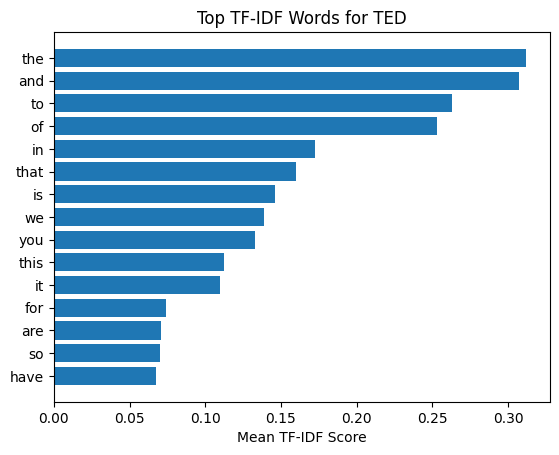

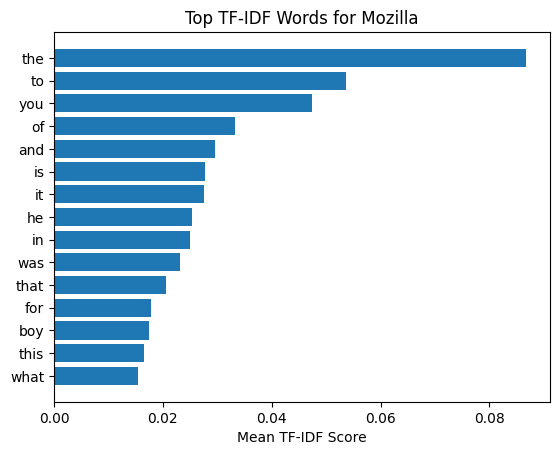

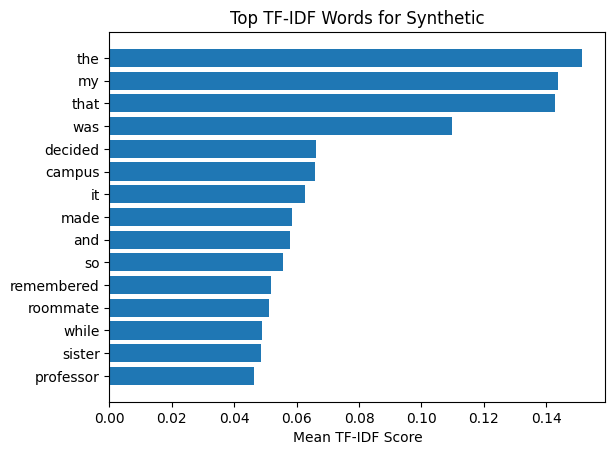

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

feature_names = np.array(vectorizer.get_feature_names_out())

def top_terms(source_name, top_n=15):
    idx = data['source'] == source_name
    X_source = X[idx.values]

    mean_tfidf = np.asarray(X_source.mean(axis=0)).ravel()  # 1D numpy array

    top_idx = mean_tfidf.argsort()[::-1][:top_n]
    terms = feature_names[top_idx]
    scores = mean_tfidf[top_idx]

    plt.figure()
    plt.barh(terms[::-1], scores[::-1])
    plt.title(f"Top TF-IDF Words for {source_name}")
    plt.xlabel("Mean TF-IDF Score")
    plt.show()

for s in data['source'].unique():
    top_terms(s)

**1. Top TF-IDF Words for TED**

The visualization shows the most important words in the TED transcripts according to their TF-IDF scores. Common words such as “the,” “and,” “to,” and “of” appear frequently, reflecting the natural structure of spoken English in speeches. Since TED talks are long conversational transcripts, many common connecting words appear prominently in the dataset.



**2. Top TF-IDF Words for Mozilla**

The Mozilla dataset also contains common English words such as “the,” “to,” “you,” and “of.” This is expected because the Mozilla Common Voice dataset consists of short spoken sentences collected from many speakers. The vocabulary reflects simple conversational phrases rather than long structured speech.

**3.Top TF-IDF Words for Synthetic Dataset**

The synthetic dataset shows a mix of common words and context-specific words such as “campus,” “roommate,” and “professor.” These words suggest that the synthetic sentences follow a narrative or story-like structure. Compared to the other datasets, the vocabulary is more specific to certain themes or situations.

##12. Splitting the Dataset into Training and Testing Sets

The dataset is divided into a training set and a testing set. The training set is used to train the models, while the testing set is used to evaluate how well the models perform on new data. This helps us measure the performance of the models.

In [ ]:
from sklearn.model_selection import train_test_split

#splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (8866, 5000)
Testing size: (2217, 5000)


#Datastet Balance Visualization

The bar chart shows the number of text samples available from each dataset source. The datasets appear realively balanced, which helps prevent bias during model training. Having comparable numbers of samples from each source allows the classification algorithms to learn patterns more fairly across datasets.

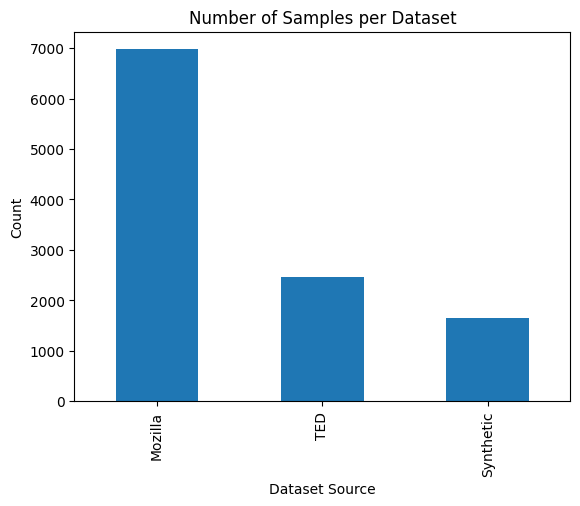

In [ ]:
import matplotlib.pyplot as plt

counts = data['source'].value_counts()

plt.figure()
counts.plot(kind='bar')
plt.title("Number of Samples per Dataset")
plt.xlabel("Dataset Source")
plt.ylabel("Count")
plt.show()

# Text Length Distribution Visualization

The visualization shows that TED transcripts are significantly longer than texts from the Mozilla and Synthetic datasets. TED speeches contain full speech transcripts, while the other datasets consist mostly of short sentences. This difference in text length indicates variation in dataset structure, which can affect feature extraction and model learning.

<Figure size 640x480 with 0 Axes>

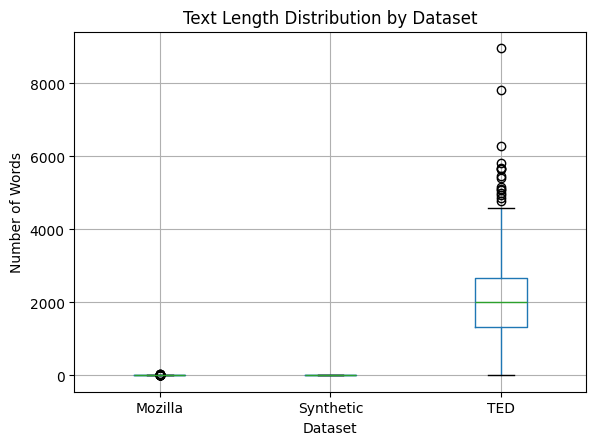

In [ ]:
data['text_len_words'] = data['text'].apply(lambda x: len(str(x).split()))

plt.figure()
data.boxplot(column='text_len_words', by='source')
plt.title("Text Length Distribution by Dataset")
plt.suptitle("")
plt.xlabel("Dataset")
plt.ylabel("Number of Words")
plt.show()

##13. Training the Naive Bayes Classification Model

In this step, the Naive Bayes classifier is trained using the training data.
Naive Bayes is commonly used for text classification because it performs well with high-dimensional text features such as TF-IDF vectors.
The model will learn patterns that help identify whether a sentence comes from the TED, Mozilla, or Synthetic dataset.

In [ ]:
from sklearn.naive_bayes import MultinomialNB

#creating the naive bayes classifier
nb_model = MultinomialNB()

#training the model using the training data
nb_model.fit(X_train, y_train)

#making predictions on the testing data
nb_predictions = nb_model.predict(X_test)

##14. Training the Logistic Regression Model

Logistic Regression is another classification algorithm used to predict the category of each text entry.
This model analyzes the relationship between the extracted features and the dataset labels.
Training multiple models allows us to compare their performance later in the experimentation stage.

In [ ]:
from sklearn.linear_model import LogisticRegression

#creating the logistic regression classifier
lr_model = LogisticRegression(max_iter=1000)

#training the model using the training data
lr_model.fit(X_train, y_train)

#making predictions on the testing data
lr_predictions = lr_model.predict(X_test)

##15. Training the Support Vector Machine (SVM) Model

The Support Vector Machine (SVM) model is trained to classify the text data into the three source categories.
SVM is effective for text classification tasks because it can handle large feature spaces and find optimal decision boundaries between classes.

In [ ]:
from sklearn.svm import LinearSVC


#creating the SVM classifier
svm_model = LinearSVC()

#training the svm model using the training data
svm_model.fit(X_train, y_train)

#making predictions on the testing data
svm_predictions = svm_model.predict(X_test)

##16. Evaluating Model Performance

After training the models, their performance is evaluated using several classification metrics. These metrics include accuracy, precision, recall, and F1-score. These measures help determine how well each model correctly classifies the text data.

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

#evaluating the naive bayes model
print("Naive Bayes Results")
print("Accuracy:", accuracy_score(y_test, nb_predictions))
print(classification_report(y_test, nb_predictions))

#evaluating the logistic regression model
print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, lr_predictions))
print(classification_report(y_test, lr_predictions))

#evaluating the svm model
print("SVM Results")
print("Accuracy:", accuracy_score(y_test, svm_predictions))
print(classification_report(y_test, svm_predictions))

Naive Bayes Results
Accuracy: 0.9589535408209292
              precision    recall  f1-score   support

     Mozilla       0.96      0.98      0.97      1404
   Synthetic       0.99      1.00      1.00       318
         TED       0.93      0.89      0.91       495

    accuracy                           0.96      2217
   macro avg       0.96      0.95      0.96      2217
weighted avg       0.96      0.96      0.96      2217

Logistic Regression Results
Accuracy: 0.9972936400541272
              precision    recall  f1-score   support

     Mozilla       1.00      1.00      1.00      1404
   Synthetic       1.00      1.00      1.00       318
         TED       1.00      0.99      0.99       495

    accuracy                           1.00      2217
   macro avg       1.00      1.00      1.00      2217
weighted avg       1.00      1.00      1.00      2217

SVM Results
Accuracy: 0.9986468200270636
              precision    recall  f1-score   support

     Mozilla       1.00      1.00   

##17. Confusion Matrix Analysis

The confusion matrix provides a detailed view of the classification results.
It shows how many instances were correctly or incorrectly predicted for each dataset source (TED, Mozilla, and Synthetic).
This helps identify which classes the models may confuse with one another.

In [ ]:
#displaying the confusion matrix for the Naive Bayes model
print("Confusion Matrix (Naive Bayes)")
print(confusion_matrix(y_test, nb_predictions))

Confusion Matrix (Naive Bayes)
[[1369    2   33]
 [   0  318    0]
 [  56    0  439]]


In [ ]:
#displaying the confusion matrix for the Logistic Regression model
print("Confusion Matrix (Logistic Regression)")
print(confusion_matrix(y_test, lr_predictions))

Confusion Matrix (Logistic Regression)
[[1404    0    0]
 [   0  318    0]
 [   6    0  489]]


In [ ]:
#displaying the confusion matrix for the svm model
print("Confusion Matrix (SVM)")
print(confusion_matrix(y_test, svm_predictions))

Confusion Matrix (SVM)
[[1404    0    0]
 [   0  318    0]
 [   3    0  492]]


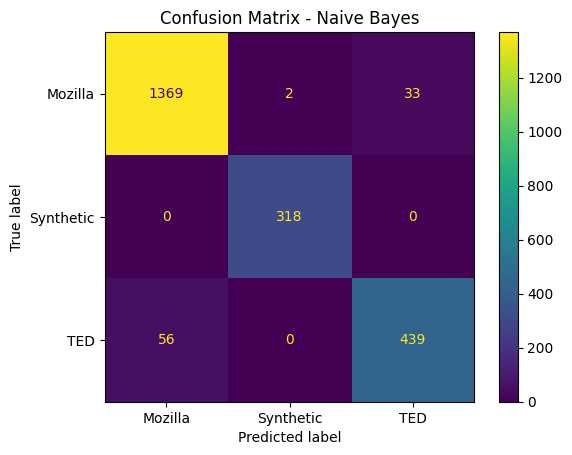

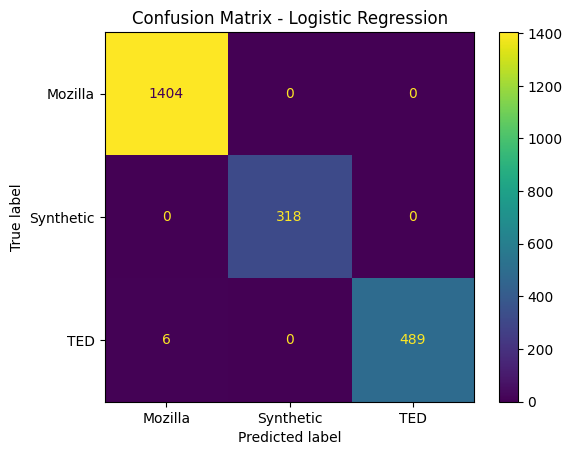

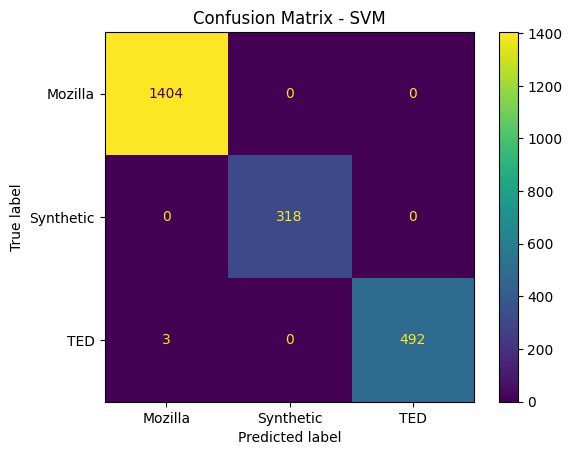

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#creating and displaying confusion matrix for all models
models = {"Naive Bayes": nb_predictions,"Logistic Regression": lr_predictions,"SVM": svm_predictions}

for model_name, predictions in models.items():
    #computing the confusion matrix
    cm = confusion_matrix(y_test, predictions)

    #creating visual display of the confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nb_model.classes_)
    disp.plot()
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

##18. Model Performance Comparison

In this step, the performance of the different classification models is compared using evaluation metrics such as accuracy, precision, recall, and F1-score. The results are organized into a table to make it easier to compare how well each model performs in classifying the text data. This helps identify which model works best for the dataset.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd

#creating a table to compare the performance of all models
results = {
    "Model": ["Naive Bayes", "Logistic Regression", "SVM"],
    "Accuracy": [accuracy_score(y_test, nb_predictions),accuracy_score(y_test, lr_predictions),accuracy_score(y_test, svm_predictions)],
    "Precision": [precision_score(y_test, nb_predictions, average='weighted'),precision_score(y_test, lr_predictions, average='weighted'),precision_score(y_test, svm_predictions, average='weighted')],
    "Recall": [recall_score(y_test, nb_predictions, average='weighted'),recall_score(y_test, lr_predictions, average='weighted'),recall_score(y_test, svm_predictions, average='weighted')],
    "F1-score": [f1_score(y_test, nb_predictions, average='weighted'),f1_score(y_test, lr_predictions, average='weighted'),f1_score(y_test, svm_predictions, average='weighted')]
    }

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1-score
0          Naive Bayes  0.958954   0.958606  0.958954  0.958630
1  Logistic Regression  0.997294   0.997305  0.997294  0.997288
2                  SVM  0.998647   0.998650  0.998647  0.998645


# Model Performance Comparision Visualization

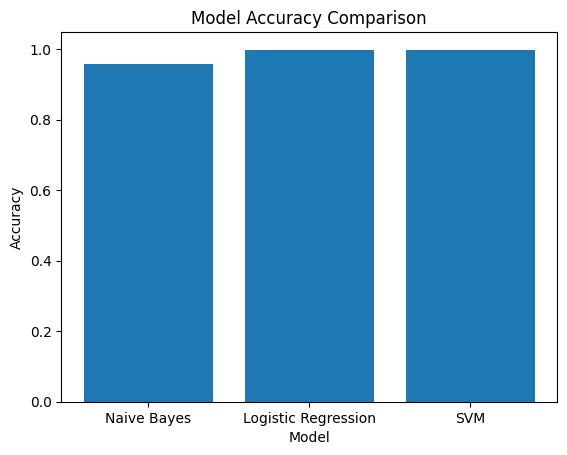

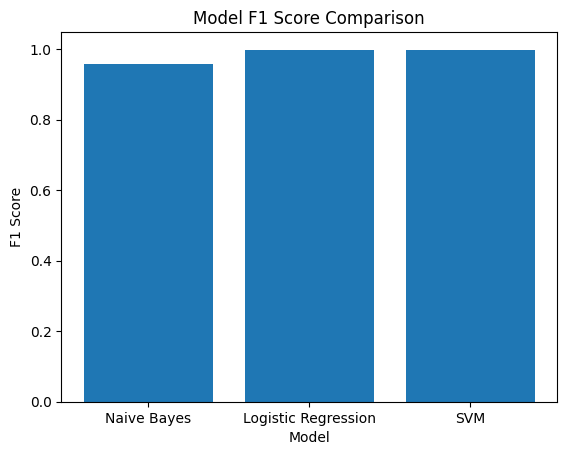

In [ ]:
plt.figure()
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

plt.figure()
plt.bar(results_df["Model"], results_df["F1-score"])
plt.title("Model F1 Score Comparison")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.show()

**Model Accuracy Comparison**

This visualization compares the accuracy of the three machine learning models: Naive Bayes, Logistic Regression, and Support Vector Machine (SVM). Logistic Regression and SVM achieve the highest accuracy, while Naive Bayes performs slightly lower. This indicates that Logistic Regression and SVM are better at learning patterns from the TF-IDF features and classifying the text sources correctly.

**Model F1 Score Comparison**

The F1-score comparison shows similar results to the accuracy graph. Logistic Regression and SVM achieve the highest F1-scores, indicating strong performance in balancing precision and recall. Naive Bayes performs slightly lower, suggesting it is somewhat less effective at distinguishing between the different text datasets.